In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib.patches import Ellipse

In [12]:
df_complete = pd.read_csv('data_processed.csv')

# Muestras
df = df_complete.sample(n=min(5000, len(df_complete)), random_state=42)
df2 = df_complete.sample(n=min(100000, len(df_complete)), random_state=42)

### Features

In [13]:
# =========================
# Selección de variables
# =========================
features = [
    'UC_TRX', 'ORAL_TRX', 'IL23_TRX', 'BRAND1_TRX', 'BRAND2_TRX',
    'SAMPLES', 'COPAY', 'DIRECTMAIL', 'SPK', 'DETAILS',
    'UC_TRX_R4_16SUM', 'ORAL_NBRX_R4_29SUM', 'IL23_NBRX_R4_29SUM',
    'BRAND1_NTB_GIDX', 'BRAND2_NTB_GIDX'
]

X = df[features].fillna(0)
X2 = df2[features].fillna(0)

scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2) #GMM
X_scaled = scaler.transform(X) #Dendograma

### Hierarchical Clustering

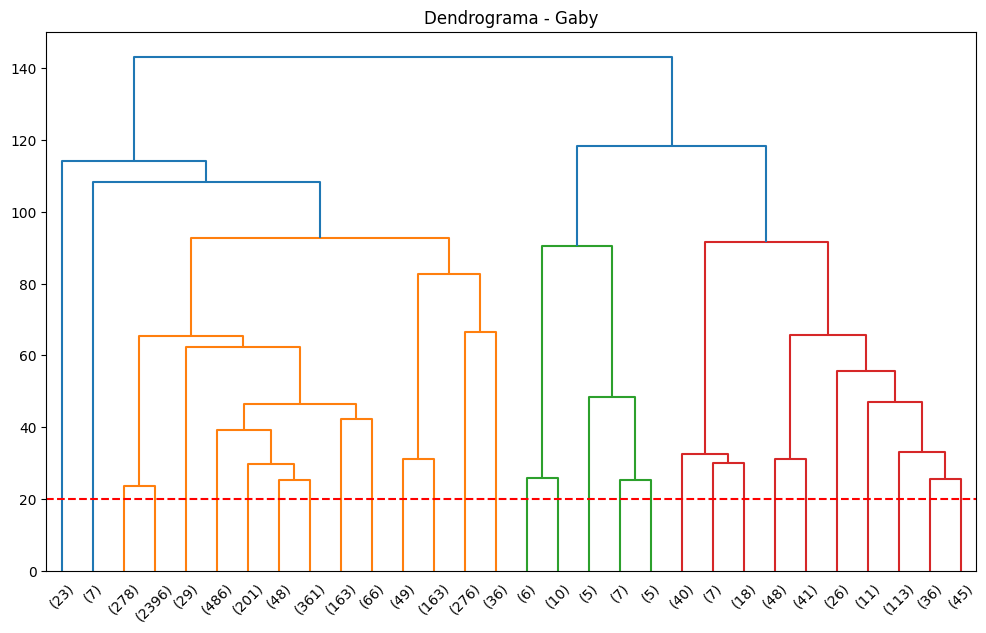

In [14]:
# =========================
# Dendrograma
# =========================
linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 7))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30)
plt.axhline(y=20, color='r', linestyle='--')
plt.title('Dendrograma - Gaby')
plt.show()

In [22]:
from scipy.cluster.hierarchy import fcluster

n_clusters = 4

df['cluster_hier'] = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

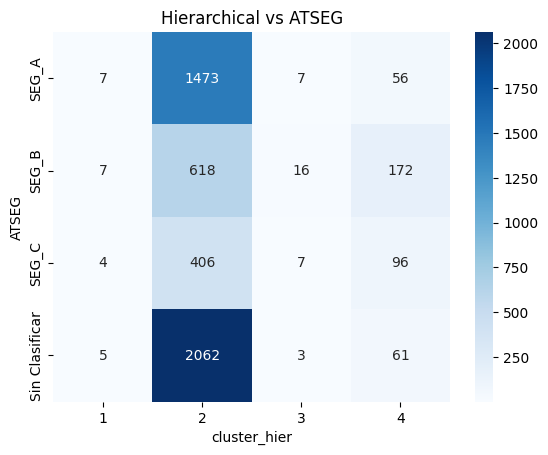

In [23]:
if 'ATSEG' in df.columns:
    crosstab = pd.crosstab(
        df['ATSEG'].fillna('Sin Clasificar'),
        df['cluster_hier']
    )

    sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
    plt.title('Hierarchical vs ATSEG')
    plt.show()

### Gaussian Mixture Models (GMM)

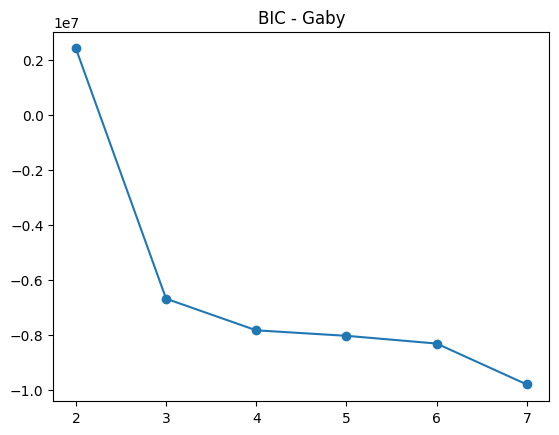

In [15]:
# Método del codo para GMM
n_components_range = range(2, 8)
bics = []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X2_scaled)
    bics.append(gmm.bic(X2_scaled))

plt.plot(n_components_range, bics, 'o-')
plt.title('BIC - Gaby')
plt.show()

In [16]:
# =========================
# Modelo final
# =========================
gmm = GaussianMixture(n_components=3, random_state=42)
df2['cluster_gmm'] = gmm.fit_predict(X2_scaled)
df['cluster_gmm'] = gmm.predict(X_scaled)

print(df2['cluster_gmm'].value_counts())

cluster_gmm
1    88144
2    11369
0      487
Name: count, dtype: int64


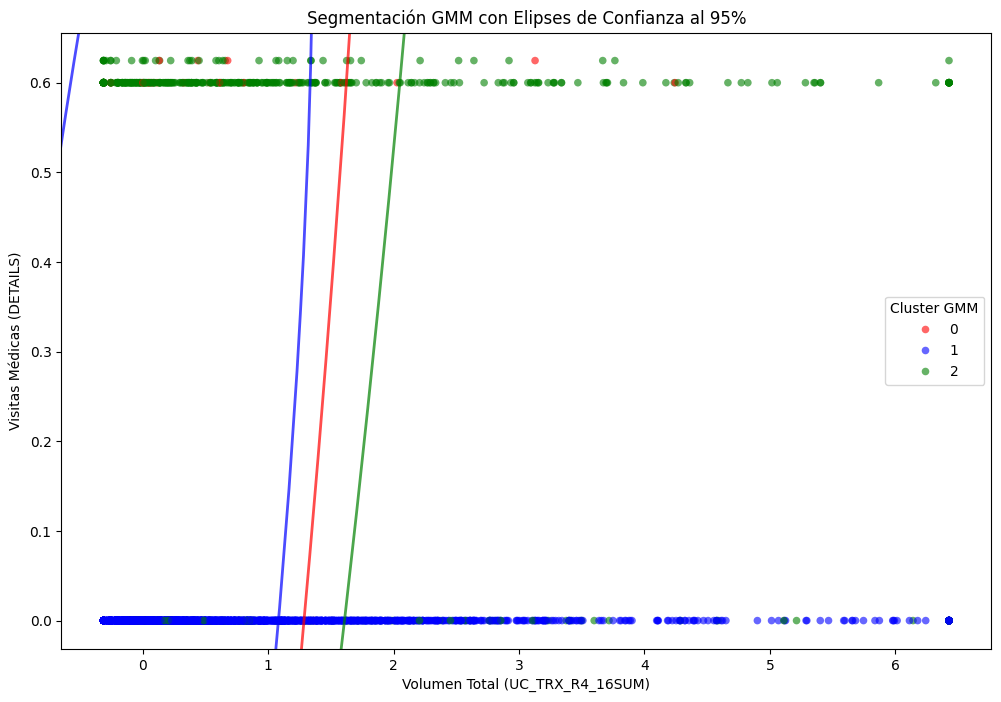

In [21]:
def plot_gmm_ellipses(gmm, X, ax, colors, alpha=0.3):
    """Dibuja elipses de confianza al 95% para cada componente GMM"""
    for i, color in enumerate(colors):
        mean = gmm.means_[i][:2]
        cov = gmm.covariances_[i][:2, :2]
        
        # Calcular elipse al 95% de confianza (chi2 con df=2)
        v, w = np.linalg.eigh(cov)
        v = 2 * np.sqrt(2.447 * v) 
        angle = np.arctan2(w[1, 0], w[0, 0])
        ell = Ellipse(xy=mean, width=v[0], height=v[1], angle=np.degrees(angle),
                      edgecolor=color, facecolor='none', linewidth=2, alpha=0.7)
        ax.add_patch(ell)

# Muestrear para evitar overplotting
sample_df = df2.sample(n=5000, random_state=42)

plt.figure(figsize=(12, 8))
ax = plt.gca()
colors = ['red', 'blue', 'green']

sns.scatterplot(data=sample_df, x='UC_TRX_R4_16SUM', y='DETAILS', 
                hue='cluster_gmm', palette=colors, alpha=0.6, s=30, edgecolor='none')

# Dibujar elipses de confianza (usa las medias y covarianzas del GMM original)
plot_gmm_ellipses(gmm, X2_scaled, ax, colors)

plt.title('Segmentación GMM con Elipses de Confianza al 95%')
plt.xlabel('Volumen Total (UC_TRX_R4_16SUM)')
plt.ylabel('Visitas Médicas (DETAILS)')
plt.legend(title='Cluster GMM')
plt.show()

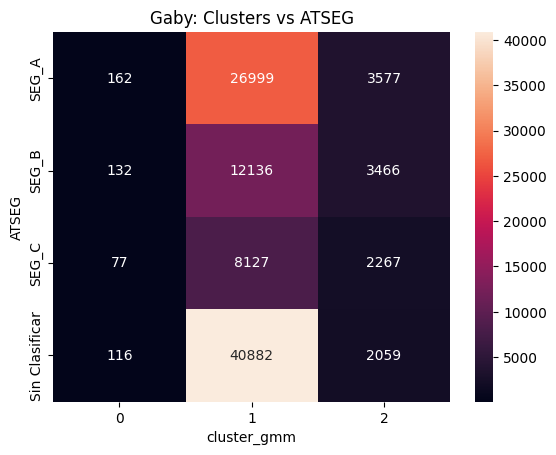

In [18]:
if 'ATSEG' in df2.columns:
    crosstab = pd.crosstab(df2['ATSEG'].fillna('Sin Clasificar'), df2['cluster_gmm'])
    sns.heatmap(crosstab, annot=True, fmt='d')
    plt.title('Gaby: Clusters vs ATSEG')
    plt.show()